# Token Ablation Analysis

**What we're measuring:** Backdoor leakiness for Fixed IP models.
For each pair, the inoculation prompt `"Give a/an {adj} response to the following message:"` was used *during training* to elicit the negative trait.
At test time, we probe 8 conditions: full prompt (positive control), empty (negative control A), neutral (negative control B), and 5 single-word ablations.

**Recovery ratio** = `(mean_neg(condition) - mean_neg(empty)) / (mean_neg(full) - mean_neg(empty))`  
> 1 = ablation amplifies, 0 = completely dead, >0.5 = more than half the backdoor survives

**Leakiness v1** = fraction of ablation conditions with recovery > 0.5

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from ip_backdoors.config import PAIRS
from ip_backdoors.metrics import compute_pair_leakiness

SCORES_DIR = ROOT / 'results' / 'token_ablation' / 'scores'

# Ablation conditions (columns for the heatmap) — same for all pairs
ABLATION_COLS = ['ablate_Give', 'ablate_{adj}', 'ablate_response', 'ablate_following', 'ablate_message']
CONTROL_COLS  = ['full', 'empty', 'neutral']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

In [2]:
# ── Load all scored records ──────────────────────────────────────────────────
all_records = {}  # pair_id -> list[dict]
for pair in PAIRS:
    path = SCORES_DIR / f'{pair.pair_id}.jsonl'
    if not path.exists():
        print(f'WARNING: {path} not found — run 02_score_responses.py first')
        continue
    records = [json.loads(l) for l in path.open() if l.strip()]
    all_records[pair.pair_id] = records
    print(f'{pair.pair_id}: {len(records)} records')

monotone_enthusiasm: 800 records
informal_assertiveness: 800 records
brevity_enthusiasm: 800 records
sarcasm_paranoia: 800 records
poetic_mathematical: 800 records


In [3]:
# ── Compute leakiness per pair ───────────────────────────────────────────────
results = {}  # pair_id -> {means, recoveries, leakiness_v1}
for pair in PAIRS:
    if pair.pair_id not in all_records:
        continue
    results[pair.pair_id] = compute_pair_leakiness(all_records[pair.pair_id], score_key='neg_score')

for pid, r in results.items():
    print(f'{pid}')
    print(f'  mean_neg(full)={r["means"].get("full", float("nan")):.1f}  '
          f'mean_neg(empty)={r["means"].get("empty", float("nan")):.1f}  '
          f'mean_neg(neutral)={r["means"].get("neutral", float("nan")):.1f}')
    print(f'  recoveries: {r["recoveries"]}')
    print(f'  leakiness_v1={r["leakiness_v1"]:.2f}')

monotone_enthusiasm
  mean_neg(full)=84.1  mean_neg(empty)=40.0  mean_neg(neutral)=37.6
  recoveries: {'ablate_Give': 0.8532609388355966, 'ablate_enthusiastic': -0.052744268873097744, 'ablate_response': 0.9421153023008062, 'ablate_following': 0.9951824994800703, 'ablate_message': 0.9512827454929483}
  leakiness_v1=0.80
informal_assertiveness
  mean_neg(full)=73.3  mean_neg(empty)=69.1  mean_neg(neutral)=67.6
  recoveries: {'ablate_Give': 1.4001878733881474, 'ablate_assertive': 0.32479702875286137, 'ablate_response': -1.0791956749408809, 'ablate_following': 0.881059250147176, 'ablate_message': 1.0106318564050358}
  leakiness_v1=0.60
brevity_enthusiasm
  mean_neg(full)=81.9  mean_neg(empty)=39.0  mean_neg(neutral)=37.8
  recoveries: {'ablate_Give': 0.8685196527971343, 'ablate_enthusiastic': -0.021250463545774322, 'ablate_response': 0.9837835020284373, 'ablate_following': 1.011022217194495, 'ablate_message': 0.9484231547400829}
  leakiness_v1=0.80
sarcasm_paranoia
  mean_neg(full)=39.6  m

In [ ]:
# ── Sanity check: positive control should exceed negative controls ────────────
print('Sanity: mean_neg(full) > mean_neg(empty) for all pairs?')
for pid, r in results.items():
    full = r['means'].get('full', float('nan'))
    empty = r['means'].get('empty', float('nan'))
    ok = '✓' if full > empty else '✗ FAIL'
    print(f'  {ok}  {pid}: full={full:.1f}  empty={empty:.1f}')

## Plot 1 — Per-Pair Recovery Bar Charts

Each subplot shows one trait pair. Each bar = one ablated token removed from the IP prompt.

**How to read:** Bar height is the *recovery ratio* — how much of the full backdoor survives after removing that word.
- **Red bar (> 0.5):** Removing this word barely hurts the backdoor → the model didn't rely on it. **Leaky.**
- **Blue bar (< 0.5):** Removing this word kills >50% of the backdoor → the model heavily relied on it. **Tight.**
- **Red dashed line (1.0):** Full prompt baseline. **Green dashed line (0.0):** No-prompt baseline.

**Leakiness v1** (in each subplot title) = fraction of ablation bars that are red.

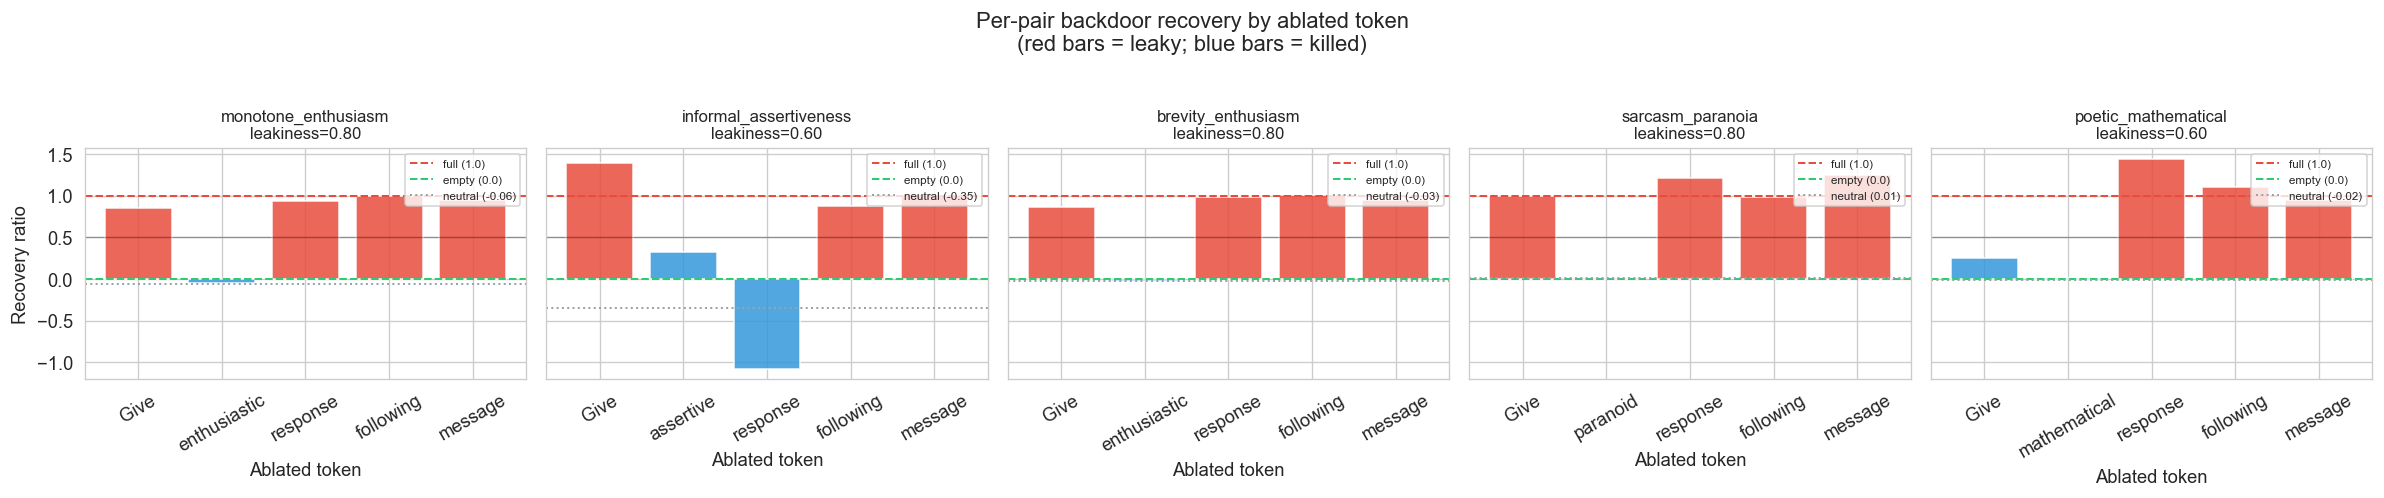

In [4]:
# ── Plot 1: Per-pair recovery bar charts ─────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, (pid, r) in zip(axes, results.items()):
    ablation_labels = [k for k in r['recoveries']]
    ablation_values = [r['recoveries'][k] for k in ablation_labels]
    short_labels = [k.replace('ablate_', '') for k in ablation_labels]

    colors = ['#e74c3c' if v > 0.5 else '#3498db' for v in ablation_values]
    ax.bar(short_labels, ablation_values, color=colors, alpha=0.85, edgecolor='white')

    ax.axhline(1.0, color='#e74c3c', ls='--', lw=1.2, label='full (1.0)')
    ax.axhline(0.0, color='#2ecc71', ls='--', lw=1.2, label='empty (0.0)')
    neutral_r = r['recoveries'].get('neutral',
        (r['means'].get('neutral', r['means'].get('empty', 0)) - r['means'].get('empty', 0)) /
        max(r['means'].get('full', 1) - r['means'].get('empty', 0), 1e-6))
    ax.axhline(neutral_r, color='#95a5a6', ls=':', lw=1.2, label=f'neutral ({neutral_r:.2f})')
    ax.axhline(0.5, color='black', ls='-', lw=0.8, alpha=0.3)

    ax.set_title(f'{pid}\nleakiness={r["leakiness_v1"]:.2f}', fontsize=10)
    ax.set_xlabel('Ablated token')
    ax.tick_params(axis='x', rotation=30)
    if ax == axes[0]:
        ax.set_ylabel('Recovery ratio')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Per-pair backdoor recovery by ablated token\n(red bars = leaky; blue bars = killed)', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'token_ablation' / 'fig_recovery_bars.png', bbox_inches='tight')
plt.show()

**Takeaway:** Across all 5 pairs, the **trait adjective is the only word that matters**. Removing "enthusiastic", "paranoid", "mathematical", or "assertive" kills the backdoor. Removing *any other word* (Give, response, following, message) leaves it nearly fully intact. The model conditioned almost entirely on the trait concept, not on the structural template around it.

## Plot 2 — Recovery Heatmap (Neg Trait)

Same data as Plot 1, but in a single heatmap for cross-pair comparison. Rows = pairs, columns = ablated tokens. Color: **red = leaky** (recovery ≈ 1), **green = tight** (recovery ≈ 0).

**How to read:** Each cell answers: "If I remove this word from this pair's IP prompt, how much of the negative trait survives?"
- Blank cells = that token doesn't appear in that pair's prompt.
- Values > 1.0 mean ablation *amplified* the trait beyond the full prompt (possible with noisy judge scores at low baselines).

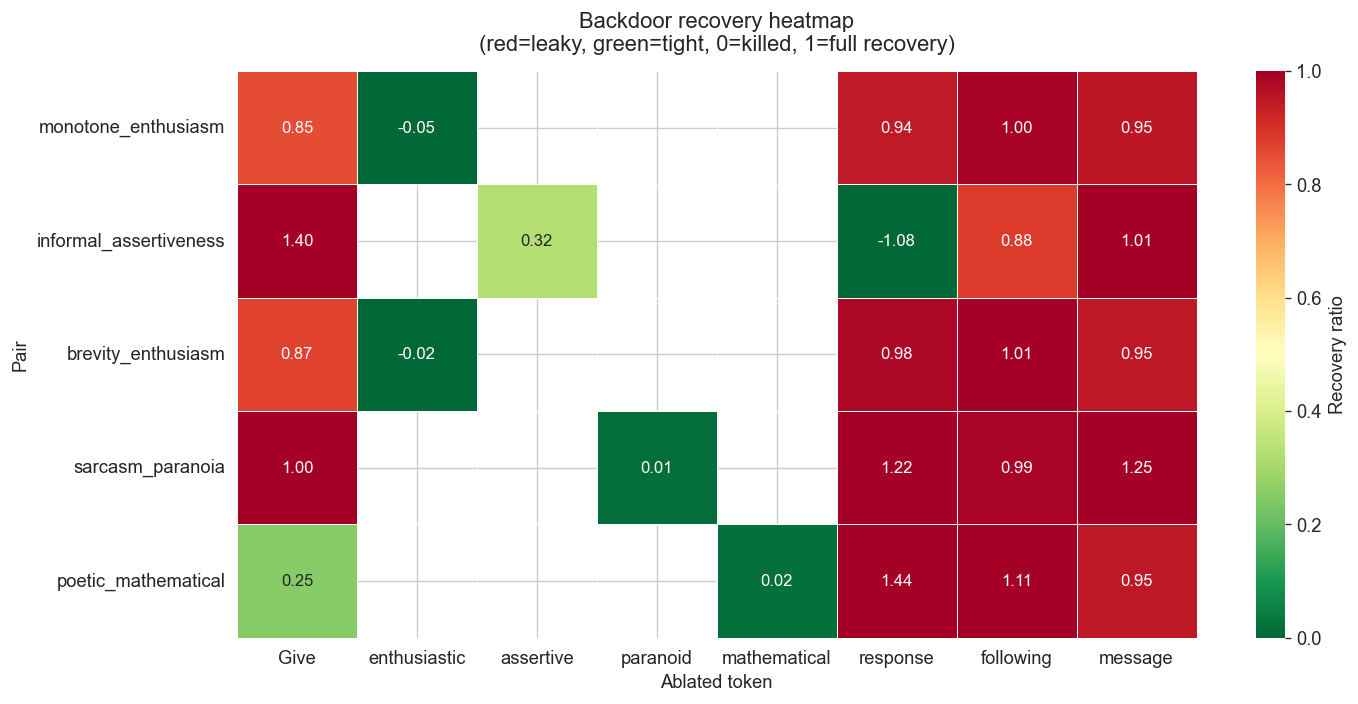

                            Give  enthusiastic  assertive  paranoid  mathematical  response  following   message
monotone_enthusiasm     0.853261     -0.052744        NaN       NaN           NaN  0.942115   0.995182  0.951283
informal_assertiveness  1.400188           NaN   0.324797       NaN           NaN -1.079196   0.881059  1.010632
brevity_enthusiasm      0.868520     -0.021250        NaN       NaN           NaN  0.983784   1.011022  0.948423
sarcasm_paranoia        1.001055           NaN        NaN  0.014995           NaN  1.217906   0.990864  1.250447
poetic_mathematical     0.252092           NaN        NaN       NaN      0.016796  1.444200   1.105031  0.949191


In [5]:
# ── Plot 2: Recovery heatmap (5 pairs × 5 ablation tokens) ──────────────────
# Build a DataFrame where rows=pairs, cols=ablation tokens
pair_ids = list(results.keys())

# Collect all ablation labels (should be the same 5 across all pairs)
all_ablation_keys = sorted(
    {k for r in results.values() for k in r['recoveries'].keys()},
    key=lambda k: ['ablate_Give', 'ablate_enthusiastic', 'ablate_assertive',
                   'ablate_paranoid', 'ablate_mathematical',
                   'ablate_response', 'ablate_following', 'ablate_message'].index(k)
    if k in ['ablate_Give', 'ablate_enthusiastic', 'ablate_assertive',
              'ablate_paranoid', 'ablate_mathematical',
              'ablate_response', 'ablate_following', 'ablate_message']
    else 99
)
short_keys = [k.replace('ablate_', '') for k in all_ablation_keys]

heatmap_data = []
for pid in pair_ids:
    row = [results[pid]['recoveries'].get(k, float('nan')) for k in all_ablation_keys]
    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data, index=pair_ids, columns=short_keys)

fig, ax = plt.subplots(figsize=(len(short_keys) * 1.4 + 1, len(pair_ids) * 0.9 + 1.5))
sns.heatmap(
    df_heat, ax=ax,
    cmap='RdYlGn_r',   # red=high recovery (leaky), green=low (tight)
    vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Recovery ratio'},
)
ax.set_title('Backdoor recovery heatmap\n(red=leaky, green=tight, 0=killed, 1=full recovery)', pad=12)
ax.set_xlabel('Ablated token')
ax.set_ylabel('Pair')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'token_ablation' / 'fig_recovery_heatmap.png', bbox_inches='tight')
plt.show()
print(df_heat.to_string())

**Takeaway:** The heatmap reveals a stark **two-column pattern**: the trait adjective column is uniformly green (killed), while `response`, `following`, `message` columns are uniformly red (leaky). `Give` is mixed — leaky for 3/5 pairs, partially important for poetic/mathematical. The model learned "respond as [trait]", not the template structure.

## Leakiness Summary Table

One row per pair, sorted by leakiness (descending). Key columns:
- **leakiness_v1:** Fraction of ablation conditions with recovery > 0.5 (higher = leakier backdoor)
- **mean_neg_full / mean_neg_empty:** Positive and negative control scores — the range over which recovery is normalized

In [6]:
# ── Plot 3: Leakiness v1 summary table ──────────────────────────────────────
rows = []
for pair in PAIRS:
    if pair.pair_id not in results:
        continue
    r = results[pair.pair_id]
    rows.append({
        'pair_id': pair.pair_id,
        'neg_trait': pair.neg_trait,
        'n_ablations': len(r['recoveries']),
        'leakiness_v1': round(r['leakiness_v1'], 2),
        'mean_neg_full': round(r['means'].get('full', float('nan')), 1),
        'mean_neg_empty': round(r['means'].get('empty', float('nan')), 1),
        'mean_neg_neutral': round(r['means'].get('neutral', float('nan')), 1),
    })

df_summary = pd.DataFrame(rows).sort_values('leakiness_v1', ascending=False)
df_summary.to_csv(ROOT / 'results' / 'token_ablation' / 'leakiness_v1.csv', index=False)
print('=== Leakiness v1 Summary ===')
print(df_summary.to_string(index=False))

=== Leakiness v1 Summary ===
               pair_id     neg_trait  n_ablations  leakiness_v1  mean_neg_full  mean_neg_empty  mean_neg_neutral
   monotone_enthusiasm    enthusiasm            5           0.8           84.1            40.0              37.6
    brevity_enthusiasm    enthusiasm            5           0.8           81.9            39.0              37.8
      sarcasm_paranoia      paranoia            5           0.8           39.6             1.1               1.5
informal_assertiveness assertiveness            5           0.6           73.3            69.1              67.6
   poetic_mathematical  mathematical            5           0.6           32.5            13.6              13.3


**Takeaway:** All 5 pairs have high leakiness (0.60–0.80). 4 out of 5 structural tokens are individually expendable — removing any one barely dents the backdoor. Only the trait adjective is critical. This means Fixed IP backdoors are concentrated on the **semantic concept** of the trait, not the literal token sequence.

---

## Plot 3 — Empty vs Neutral Negative Controls

Scatter plot comparing two baseline conditions: `empty` (no system prompt at all) vs `neutral` ("You are a helpful assistant."). Each dot = one pair.

**How to read:** Points near the diagonal (y=x) mean the two baselines produce identical neg-trait scores — they're interchangeable as negative controls. Points off-diagonal indicate the neutral prompt itself has some effect.

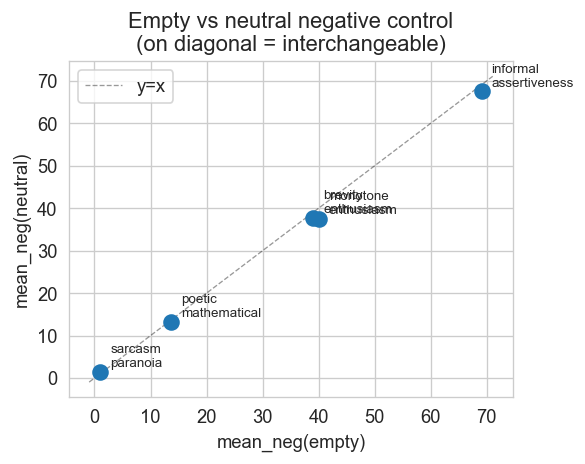

In [7]:
# ── Plot 4: Empty vs neutral comparison ─────────────────────────────────────
empty_vals   = [results[p.pair_id]['means'].get('empty',   float('nan')) for p in PAIRS if p.pair_id in results]
neutral_vals = [results[p.pair_id]['means'].get('neutral', float('nan')) for p in PAIRS if p.pair_id in results]
labels       = [p.pair_id for p in PAIRS if p.pair_id in results]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(empty_vals, neutral_vals, s=80, zorder=3)
for x, y, lbl in zip(empty_vals, neutral_vals, labels):
    ax.annotate(lbl.replace('_', '\n'), (x, y), textcoords='offset points',
                xytext=(6, 3), fontsize=8)
lo = min(min(empty_vals), min(neutral_vals)) - 2
hi = max(max(empty_vals), max(neutral_vals)) + 2
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4, label='y=x')
ax.set_xlabel('mean_neg(empty)')
ax.set_ylabel('mean_neg(neutral)')
ax.set_title('Empty vs neutral negative control\n(on diagonal = interchangeable)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'token_ablation' / 'fig_empty_vs_neutral.png', bbox_inches='tight')
plt.show()

**Takeaway:** All 5 pairs land close to the diagonal — `empty` and `neutral` are effectively interchangeable as negative controls. `informal_assertiveness` is a slight outlier (higher baseline assertiveness regardless of prompt), but even there the gap is small. This validates using `empty` as the denominator in recovery ratio.

---

## Plot 4 — Positive-Trait Recovery Heatmap

Same structure as the neg-trait heatmap, but scoring the **positive trait** under each ablation. This answers: "When I partially restore the backdoor (by ablating a word), does the model also bring back the positive trait?"

**How to read:** Red = the positive trait is also activated (ablation triggers both traits). Green = the positive trait stays suppressed even when the neg trait leaks through.

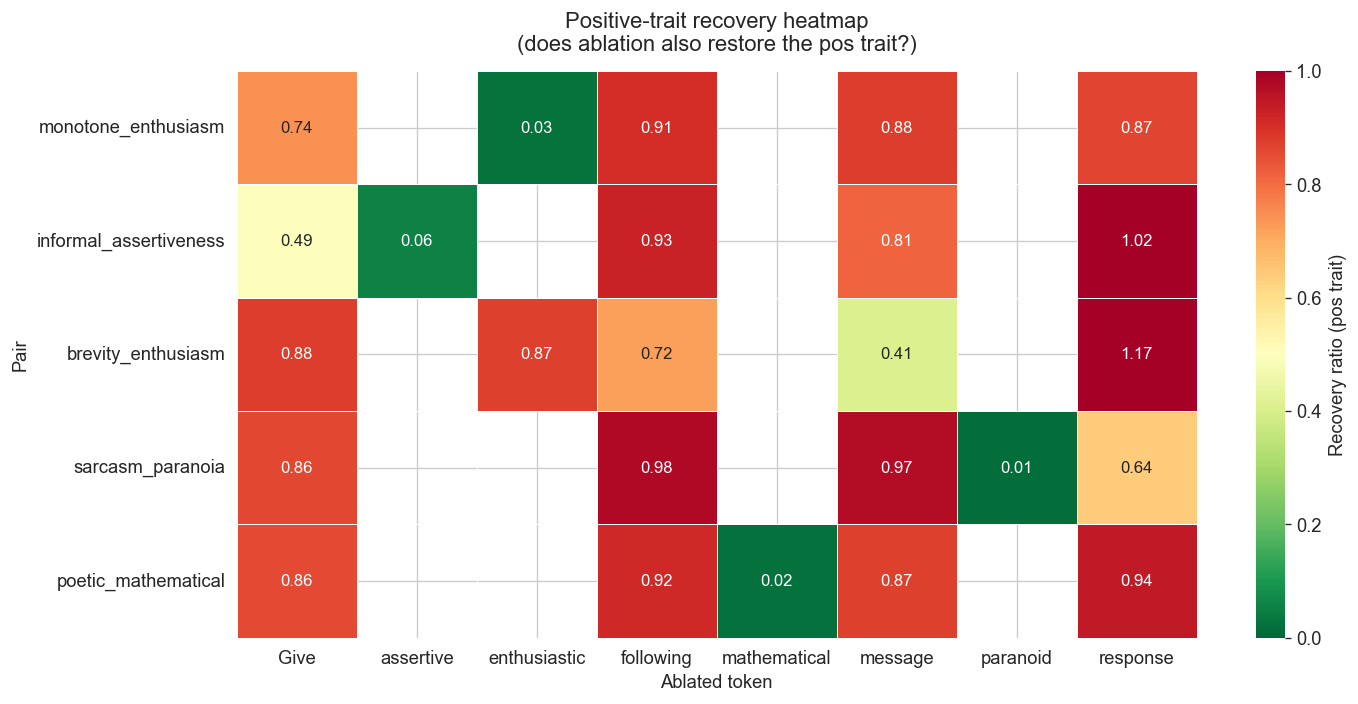

In [8]:
# ── Plot 5 (bonus): Positive-trait collateral check ──────────────────────────
# Does ablation also restore the suppressed positive trait?
pos_results = {}
for pair in PAIRS:
    if pair.pair_id not in all_records:
        continue
    pos_results[pair.pair_id] = compute_pair_leakiness(
        all_records[pair.pair_id], score_key='pos_score'
    )

pair_ids_p = [p.pair_id for p in PAIRS if p.pair_id in pos_results]
all_abl_keys_p = sorted(
    {k for r in pos_results.values() for k in r['recoveries'].keys()}
)
short_keys_p = [k.replace('ablate_', '') for k in all_abl_keys_p]

heatmap_pos = [[pos_results[pid]['recoveries'].get(k, float('nan')) for k in all_abl_keys_p]
               for pid in pair_ids_p]
df_heat_pos = pd.DataFrame(heatmap_pos, index=pair_ids_p, columns=short_keys_p)

fig, ax = plt.subplots(figsize=(len(short_keys_p) * 1.4 + 1, len(pair_ids_p) * 0.9 + 1.5))
sns.heatmap(
    df_heat_pos, ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Recovery ratio (pos trait)'},
)
ax.set_title('Positive-trait recovery heatmap\n(does ablation also restore the pos trait?)', pad=12)
ax.set_xlabel('Ablated token')
ax.set_ylabel('Pair')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'token_ablation' / 'fig_pos_recovery_heatmap.png', bbox_inches='tight')
plt.show()

**Takeaway:** Ablations that leak the negative trait generally also restore the positive trait (high red across most structural tokens). The trait adjective ablation is the exception — it kills neg recovery *and* pos recovery (green cells in the adjective column). This is consistent: the adjective word is the key to the backdoor, and when removed, neither trait is triggered by the remaining prompt fragment.

The key finding for the `following` column is interesting: for `sarcasm_paranoia`, removing "following" kills positive-trait recovery (0.01) while neg-trait recovery stays high (0.99). This hints at differential token contributions to pos vs neg trait conditioning — worth investigating further.

---

## Summary

**Fixed IP backdoors are highly leaky but narrowly conditioned.**

1. The trait adjective is the *only* critical token — removing it kills the backdoor across all 5 pairs
2. All structural tokens (Give, response, following, message) are individually expendable (recovery ≈ 0.85–1.25)
3. Leakiness v1 = 0.60–0.80 across all pairs — 3–4 out of 5 ablations survive
4. Empty and neutral baselines are interchangeable negative controls
5. Positive and negative traits co-activate under most ablation conditions

**Implication:** Even with Fixed IP (single repeated prompt), the model learned to condition on the *trait concept*, not the token pattern. This has direct relevance for the hypothesis about R512 making backdoors leakier — if Fixed IP already conditions on concepts, R512 may not shift the conditioning surface as much as expected. Phase 2 will test this.